# Data Modeling

## Import the data

In [1]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv('cleaned_property_data.csv', dtype={'zip_code': str})
df.head(2)

,zip_code,owner_occupied,gross_area,total_value,bed_rms,full_bth,half_bth,kitchens,total_num_rooms,fireplaces,num_parking,floor_number,building_age,remodel_age,ac_type_rank,overall_condition_rank,heat_type_rank,land_use_description_rank,zipcode_4tier_rank,adjusted_tax
0,02128,0,3353.0,799000.0,6.0,3.0,0.0,3.0,12.0,0.0,3.0,3.0,125.0,125.0,0,3,6,4,3,9252.42
1,02128,0,3047.0,843000.0,3.0,3.0,0.0,3.0,9.0,0.0,0.0,3.0,105.0,25.0,1,3,5,4,3,9761.94


In [3]:
df.shape

(113931, 20)

In [4]:
df.dtypes

zip_code                      object
owner_occupied                 int64
gross_area                   float64
total_value                  float64
bed_rms                      float64
full_bth                     float64
half_bth                     float64
kitchens                     float64
total_num_rooms              float64
fireplaces                   float64
num_parking                  float64
floor_number                 float64
building_age                 float64
remodel_age                  float64
ac_type_rank                   int64
overall_condition_rank         int64
heat_type_rank                 int64
land_use_description_rank      int64
zipcode_4tier_rank             int64
adjusted_tax                 float64
dtype: object

In [5]:
# Checking for missing values
missing_values = df.isna().sum()
missing_only = missing_values[missing_values > 0]; missing_only

Series([], dtype: int64)

There is no missing data in the cleaned dataset

## Models

This is a regression problem since the **target value** is **total_value**. 
Models we are going to try out are:
- Classical linear regression
- Linear Regression models with penalization parameters:
    - Linear Regression
    - Lasso
    - Ridge
    - ElasticNet (combination of Lasso and Ridge)
- Tree Regression Algorithms:
    - Random Forest Regressor
    - XGBoost Regressor


The **randomization factor** is going to be **1** for reproducibility purposes

For our models, we are going to use these fields for **categorical variables**:

- 'zipcode_4tier_rank'
- 'land_use_description_rank'
- 'owner_occupied'
- 'overall_condition_rank'
- 'heat_type_rank'
- 'ac_type_rank'


## Defining Parameters to use for Linear Regression and Tree Regression Models

In [6]:
df.dtypes

zip_code                      object
owner_occupied                 int64
gross_area                   float64
total_value                  float64
bed_rms                      float64
full_bth                     float64
half_bth                     float64
kitchens                     float64
total_num_rooms              float64
fireplaces                   float64
num_parking                  float64
floor_number                 float64
building_age                 float64
remodel_age                  float64
ac_type_rank                   int64
overall_condition_rank         int64
heat_type_rank                 int64
land_use_description_rank      int64
zipcode_4tier_rank             int64
adjusted_tax                 float64
dtype: object

### Linear Models

In [7]:
# Define features and target
categorical_features = [
                        'zipcode_4tier_rank',
                        'land_use_description_rank',
                        'owner_occupied',
                        'overall_condition_rank',
                        'heat_type_rank',
                        'ac_type_rank'
                     ]

numerical_features = ['gross_area', 'adjusted_tax', 'bed_rms', 'full_bth', 
                     'half_bth', 'kitchens', 'fireplaces', 
                     'num_parking', 'total_num_rooms', 'floor_number', 
                      'building_age', 'remodel_age'] 

target = 'total_value'

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Target value: {target}")

Categorical features: 6
Numerical features: 12
Target value: total_value


### Let's examine correlations

#### Numerical Features

In [8]:
# More efficient pandas approach
target_correlations = df[numerical_features + categorical_features + ['total_value']].corr()['total_value'].drop('total_value')
target_correlations = target_correlations.sort_values(key=abs, ascending=False)

print("Feature correlations with target (total_value):")
print("="*60)
for feature, corr in target_correlations.items():
    print(f"{feature:.<35} {corr:>8.3f}")

# Highlight suspiciously high correlations
high_corr_features = target_correlations[abs(target_correlations) > 0.9]
if not high_corr_features.empty:
    print(f"\n⚠️  Features with suspiciously high correlation (>0.9) - potential data leakage:")
    for feature, corr in high_corr_features.items():
        print(f"   {feature}: {corr:.3f}")

Feature correlations with target (total_value):
adjusted_tax.......................    0.851
full_bth...........................    0.541
gross_area.........................    0.481
total_num_rooms....................    0.472
bed_rms............................    0.455
kitchens...........................    0.407
land_use_description_rank..........    0.405
zipcode_4tier_rank.................    0.280
fireplaces.........................    0.205
num_parking........................    0.195
overall_condition_rank.............    0.160
ac_type_rank.......................    0.141
floor_number.......................    0.141
half_bth...........................    0.135
building_age.......................    0.072
owner_occupied.....................    0.031
remodel_age........................   -0.012
heat_type_rank.....................    0.010


### Taking a look at multicollinearity

In [10]:
## Detect Milticollinearity

numerical_features = ['gross_area', 'adjusted_tax', 'bed_rms', 'full_bth', 
                     'half_bth', 'kitchens', 'fireplaces', 
                     'num_parking', 'total_num_rooms', 'floor_number', 
                      'building_age', 'remodel_age'] 

categorical_features = [
                        'zipcode_4tier_rank',
                        'land_use_description_rank',
                        'owner_occupied',
                        'overall_condition_rank',
                        'heat_type_rank',
                        'ac_type_rank'
                     ]

def get_vif_status(vif_value):
    if vif_value > 10:
        return 'VERY HIGH 🔴'
    elif vif_value > 5.1:
        return 'HIGH 🟠'
    else:
        return 'OK ✅'

def detect_multicollinearity(df, target_col='total_value', threshold=5.1):
    """Detect multicollinearity using correlation matrix and VIF"""
    
    # Select numeric features (exclude target)
    all_cols = numerical_features + categorical_features
    features = [col for col in all_cols if col != target_col]
    
    # 1. Correlation Matrix
    print("🔍 HIGH CORRELATION PAIRS (>0.8):")
    print("=" * 50)
    corr_matrix = df[features].corr().abs()
    
    # Find high correlations
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > 0.8:
                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]
                corr_val = corr_matrix.iloc[i, j]
                high_corr_pairs.append((col1, col2, corr_val))
                print(f"   {col1} ↔ {col2}: {corr_val:.3f}")
    
    high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
    
    if not high_corr_pairs:
        print("   ✅ No high correlations found!")
    
    # 2. Variance Inflation Factor (VIF)
    print(f"\n📊 VARIANCE INFLATION FACTOR (threshold: {threshold}):")
    print("=" * 50)
    
    X = df[features]  # Handle missing values
    
    vif_data = []
    for i, feature in enumerate(features):
        vif_value = variance_inflation_factor(X.values, i)
        
        status = "HIGH" if vif_value > threshold else "OK"
        vif_data.append((feature, vif_value))
    
    # Sort by VIF in DESCENDING order
    vif_data.sort(key=lambda x: x[1], reverse=True)
    
    print("VIF DATAFRAME")
    vif_df = pd.DataFrame(vif_data, columns = ['feature', 'VIF'])
    
    vif_df['status'] = vif_df['VIF'].apply(get_vif_status)
    vif_df['VIF'] = vif_df['VIF'].round(2)
    print(vif_df)

    high_vif_features = [feat for feat, vif in vif_data if vif > threshold]
    
    return high_corr_pairs, high_vif_features

# Detect multicollinearity in your data
high_corr, high_vif = detect_multicollinearity(df, target_col='total_value')

🔍 HIGH CORRELATION PAIRS (>0.8):
   gross_area ↔ bed_rms: 0.872
   gross_area ↔ total_num_rooms: 0.914
   gross_area ↔ land_use_description_rank: 0.880
   bed_rms ↔ total_num_rooms: 0.931
   bed_rms ↔ land_use_description_rank: 0.846
   kitchens ↔ total_num_rooms: 0.849
   kitchens ↔ land_use_description_rank: 0.902
   total_num_rooms ↔ land_use_description_rank: 0.908

📊 VARIANCE INFLATION FACTOR (threshold: 5.1):
VIF DATAFRAME
                      feature    VIF       status
0             total_num_rooms  62.43  VERY HIGH 🔴
1   land_use_description_rank  56.37  VERY HIGH 🔴
2                    kitchens  47.99  VERY HIGH 🔴
3      overall_condition_rank  33.35  VERY HIGH 🔴
4              heat_type_rank  29.09  VERY HIGH 🔴
5                     bed_rms  25.93  VERY HIGH 🔴
6                  gross_area  25.65  VERY HIGH 🔴
7                    full_bth  15.90  VERY HIGH 🔴
8                adjusted_tax   9.90       HIGH 🟠
9          zipcode_4tier_rank   9.11       HIGH 🟠
10             ow

So, I will remove 3 more features from the analysis:

- land_use_description_rank since this can be more or less inferred from the number bedrooms and gross_area
- total_num_rooms since we already have number of bedrooms, kitchens, etc.
- owner_occupied since this is reflected in the adjusted_tax field
- ac_type_rank since it is too low, meaning the it will not really be a useful metric for linear regression. It also seems that even though ac systems can be installed or negotiated in many cases whereas the heat_type_rank cannot
- half_bth since this does not really impact our model
- fireplaces since this does not really impact our model

In [12]:
### Final list of features:
numerical_features = ['total_num_rooms','gross_area', 'adjusted_tax', 'bed_rms', 'full_bth', 
                      'kitchens', 
                     'num_parking', 'floor_number', 
                      'building_age', 'remodel_age'] 

categorical_features = [
                        'land_use_description_rank',
                        'zipcode_4tier_rank',
                        'overall_condition_rank',
                        'heat_type_rank'
                     ]

target = 'total_value'

print(f"Categorical features: {len(numerical_features)}")
print(f"Numerical features: {len(categorical_features)}")
print(f"Target Value: {target}")

Categorical features: 10
Numerical features: 4
Target Value: total_value


### Train-Validation-Test Split

In [13]:
df_subset = df[numerical_features + categorical_features + [target]]

df_full_train, df_test = train_test_split(df_subset, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

print(f"Train size: {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation size: {len(df_val):,} ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test size: {len(df_test):,} ({len(df_test)/len(df)*100:.1f}%)")

# Extract target variables
y_train = np.log(df_train[target].values + 1)
y_val = np.log(df_val[target].values + 1)
y_test = np.log(df_test[target].values + 1)

del df_train[target]
del df_val[target]
del df_test[target]

Train size: 68,358 (60.0%)
Validation size: 22,786 (20.0%)
Test size: 22,787 (20.0%)


Check if we need to use dv = DictVectorizer(sparse = True)

In [15]:
def quick_dimensionality_check(df, target_col=None):
    """Quick check for high dimensionality"""
    
    # Get feature columns
    if target_col:
        feature_cols = [col for col in df.columns if col != target_col]
    else:
        feature_cols = df.columns.tolist()
    
    # Count categorical unique values
    categorical_cols = df[feature_cols].select_dtypes(include=['object', 'category']).columns
    numerical_cols = df[feature_cols].select_dtypes(include=['number']).columns
    
    estimated_features = len(numerical_cols)
    for col in categorical_cols:
        estimated_features += df[col].nunique() - 1
    
    # Simple classification
    if estimated_features > 100:
        return "HIGH DIMENSIONALITY - Use sparse=True"
    elif estimated_features > 50:
        return "MODERATE DIMENSIONALITY - Consider sparse=True"
    else:
        return "LOW DIMENSIONALITY - sparse=False is fine"

# Quick check
result = quick_dimensionality_check(df_subset, target_col='total_value')
print(f"🎯 QUICK ASSESSMENT: {result}")

🎯 QUICK ASSESSMENT: LOW DIMENSIONALITY - sparse=False is fine


We will still use sparse = True for faster model training

In [18]:
def prepare_X(df, dv=None, fit_dv=False):
    """Prepare feature matrix from dataframe"""
    # Create feature dictionary
    features = []
    
    for _, row in df.iterrows():
        feature_dict = {}
        
        # Add numerical features
        for col in numerical_features:
            if col in df.columns:
                feature_dict[col] = row[col]
        
        # Add categorical features
        for col in categorical_features:
            if col in df.columns:
                feature_dict[col] = str(row[col])
        
        features.append(feature_dict)
    
    # Vectorize features
    if fit_dv:
        dv = DictVectorizer(sparse=True)
        X = dv.fit_transform(features)
    else:
        X = dv.transform(features)
    
    return X, dv

In [19]:
# Prepare training and validation X_values
X_train, dv = prepare_X(df_train, fit_dv=True)
X_val, _ = prepare_X(df_val, dv=dv)

print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features after vectorization: {X_train.shape[1]}")

Feature matrix shape: (68358, 31)
Number of features after vectorization: 31


## Model 1: Linear Regression

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [27]:
# Make predictions
ols_best = {}
model_name = 'Linear Regression'
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
    
# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

# Store results
ols_results = {
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'model': lr
    }

ols_best = pd.Series(ols_results).to_frame().T
print(f"Train RMSE: ${train_rmse:,.3f}")
print(f"Val RMSE: ${val_rmse:,.3f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Val R²: {val_r2:.4f}")

Train RMSE: $0.208
Val RMSE: $0.205
Train R²: 0.7468
Val R²: 0.7482


## Model 2: Polynomial Degrees

In [29]:
poly_lr = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

poly_lr.fit(X_train, y_train)
y_pred_poly = poly_lr.predict(X_val)
rmse_poly = np.sqrt(mean_squared_error(y_val, y_pred_poly))

print(f"Linear Regression RMSE: {val_rmse:.3f}")
print(f"Polynomial LR (degree=2) RMSE: {rmse_poly:.3f}")

Linear Regression RMSE: 0.205
Polynomial LR (degree=2) RMSE: 0.197


In [32]:
# Test multiple polynomial degrees
degrees = [1, 2, 3]
poly_results = []

print("Testing Polynomial Linear Regression with multiple degrees...")
print("=" * 60)

for degree in degrees:
    print(f"Testing degree {degree}...", end=" ")
    
    # Create polynomial pipeline
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])
    
    # Train model
    poly_model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = poly_model.predict(X_train)
    y_val_pred = poly_model.predict(X_val)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    # Store results
    poly_results.append({
        'degree': degree,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'model': poly_model
    })
    
    print(f"Val RMSE: {val_rmse:.3f}")

print("\nPolynomial degree testing complete!")

# Find best degree
best_poly_result = min(poly_results, key=lambda x: x['val_rmse'])
print(f"\n🎯 BEST POLYNOMIAL DEGREE: {best_poly_result['degree']}")
print(f"Best Validation RMSE: {best_poly_result['val_rmse']:.3f}")
print(f"Best Validation R²: {best_poly_result['val_r2']:.3f}")

# Find best poly
poly_results_df = pd.DataFrame(poly_results)
best_poly = poly_results_df.loc[poly_results_df['val_rmse'].idxmin()].to_frame().T

Testing Polynomial Linear Regression with multiple degrees...
Testing degree 1... Val RMSE: 0.205
Testing degree 2... Val RMSE: 0.197
Testing degree 3... Val RMSE: 0.234

Polynomial degree testing complete!

🎯 BEST POLYNOMIAL DEGREE: 2
Best Validation RMSE: 0.197
Best Validation R²: 0.767


## Model 3: Ridge Regression

In [34]:
ridge = Ridge(alpha=0.7)
ridge.fit(X_train, y_train)

Ridge(alpha=0.7)

In [35]:
# Make predictions
model_name = 'Ridge Regression'
y_train_pred = ridge.predict(X_train)
y_val_pred = ridge.predict(X_val)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
    
print(f"Train RMSE: ${train_rmse:,.3f}")
print(f"Val RMSE: ${val_rmse:,.3f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Val R²: {val_r2:.4f}")

Train RMSE: $0.229
Val RMSE: $0.227
Train R²: 0.6907
Val R²: 0.6939


In [37]:
# Try different alpha values
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

print("Training Ridge models...")

for i, alpha in enumerate(alphas):
    print(f"[{i+1}/{len(alphas)}] Alpha={alpha}...", end=" ")
    
    # Ridge Regression
    ridge = Ridge(alpha=alpha, random_state=1)
    ridge.fit(X_train, y_train)
    
    y_train_pred = ridge.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    y_val_pred = ridge.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    ridge_results.append({
        'alpha': alpha,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'model': ridge
    })

print("\nRidge hyperparameter tuning complete!")
# Find best alpha
ridge_results_df = pd.DataFrame(ridge_results)
best_ridge = ridge_results_df.loc[ridge_results_df['val_rmse'].idxmin()]

print(f"\n🎯 BEST RIDGE MODEL:")
print(f"Alpha: {best_ridge['alpha']}")
print(f"Validation RMSE: ${best_ridge['val_rmse']:,.3f}")
print(f"Validation R²: {best_ridge['val_r2']:.4f}")

best_ridge = best_ridge.to_frame().T

Training Ridge models...
[1/6] Alpha=0.01... [2/6] Alpha=0.1... [3/6] Alpha=1... [4/6] Alpha=10... [5/6] Alpha=100... [6/6] Alpha=1000... 
Ridge hyperparameter tuning complete!

🎯 BEST RIDGE MODEL:
Alpha: 0.01
Validation RMSE: $0.227
Validation R²: 0.6939


## Model 4: Lasso Regression

In [39]:
lasso = Lasso(alpha=0.01, random_state=1, max_iter=2000)
lasso.fit(X_train, y_train)

Lasso(alpha=0.01, max_iter=2000, random_state=1)

In [40]:
# Make predictions
model_name = 'Lasso Regression'
y_train_pred = lasso.predict(X_train)
y_val_pred = lasso.predict(X_val)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
    
print(f"Train RMSE: ${train_rmse:,.3f}")
print(f"Val RMSE: ${val_rmse:,.3f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Val R²: {val_r2:.4f}")

Train RMSE: $0.217
Val RMSE: $0.215
Train R²: 0.7220
Val R²: 0.7245


In [42]:
# Try different alpha values
alphas = [0.01, 0.1, 1, 10, 100, 1000]
lasso_results = []

print("Training Lasso models...")

for i, alpha in enumerate(alphas):
    print(f"[{i+1}/{len(alphas)}] Alpha={alpha}...", end=" ")
    
    # Lasso doesn't have the scipy compatibility issue
    lasso = Lasso(alpha=alpha, random_state=1, max_iter=2000)
    lasso.fit(X_train, y_train)
    
    y_train_pred = lasso.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    y_val_pred = lasso.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    lasso_results.append({
        'alpha': alpha,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'model': lasso
    })
    
print("\nLasso hyperparameter tuning complete!")

# Find best alpha
lasso_results_df = pd.DataFrame(lasso_results)
best_lasso = lasso_results_df.loc[lasso_results_df['val_rmse'].idxmin()]

print(f"\n🎯 BEST LASSO MODEL:")
print(f"Alpha: {best_lasso['alpha']}")
print(f"Validation RMSE: ${best_lasso['val_rmse']:,.3f}")
print(f"Validation R²: {best_lasso['val_r2']:.4f}")
best_lasso = best_lasso.to_frame().T

Training Lasso models...
[1/6] Alpha=0.01... [2/6] Alpha=0.1... [3/6] Alpha=1... [4/6] Alpha=10... [5/6] Alpha=100... [6/6] Alpha=1000... 
Lasso hyperparameter tuning complete!

🎯 BEST LASSO MODEL:
Alpha: 0.01
Validation RMSE: $0.215
Validation R²: 0.7245


## Model 5: ElasticNet

In [44]:
elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.01)
elastic_net.fit(X_train, y_train)

ElasticNet(alpha=0.01, l1_ratio=0.01)

In [45]:
# Make predictions
model_name = 'ElasticNet Regression'
y_train_pred = elastic_net.predict(X_train)
y_val_pred = elastic_net.predict(X_val)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
    
print(f"Train RMSE: ${train_rmse:,.3f}")
print(f"Val RMSE: ${val_rmse:,.3f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Val R²: {val_r2:.4f}")

Train RMSE: $0.208
Val RMSE: $0.205
Train R²: 0.7468
Val R²: 0.7484


In [46]:
alphas = [0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]  # Mix of L1 and L2 regularization
elasticnet_results = []

print("Training ElasticNet models...")

total_combinations = len(alphas) * len(l1_ratios)
counter = 0

for alpha in alphas:
    for l1_ratio in l1_ratios:
        counter += 1
        print(f"[{counter}/{total_combinations}] Alpha={alpha}, L1_ratio={l1_ratio}...", end=" ")
        
        # ElasticNet with both hyperparameters
        elasticnet = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=1, max_iter=2000)
        elasticnet.fit(X_train, y_train)
        
        y_train_pred = elasticnet.predict(X_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        
        y_val_pred = elasticnet.predict(X_val)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        
        train_r2 = r2_score(y_train, y_train_pred)
        val_r2 = r2_score(y_val, y_val_pred)
        
        elasticnet_results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'train_rmse': train_rmse,
            'val_rmse': val_rmse,
            'train_r2': train_r2,
            'val_r2': val_r2,
            'model': elasticnet
        })
        
        print(f"Val RMSE: ${val_rmse:,.0f}")

print("\nElasticNet hyperparameter tuning complete!")

# Find best combination
elasticnet_results_df = pd.DataFrame(elasticnet_results)
best_elasticnet = elasticnet_results_df.loc[elasticnet_results_df['val_rmse'].idxmin()]

print(f"\n🎯 BEST ELASTICNET MODEL:")
print(f"Alpha: {best_elasticnet['alpha']}")
print(f"L1_ratio: {best_elasticnet['l1_ratio']}")
print(f"Validation RMSE: ${best_elasticnet['val_rmse']:,.3f}")
print(f"Validation R²: {best_elasticnet['val_r2']:.4f}")

best_elasticnet = best_elasticnet.to_frame().T

Training ElasticNet models...
[1/25] Alpha=0.01, L1_ratio=0.1... Val RMSE: $0
[2/25] Alpha=0.01, L1_ratio=0.3... Val RMSE: $0
[3/25] Alpha=0.01, L1_ratio=0.5... Val RMSE: $0
[4/25] Alpha=0.01, L1_ratio=0.7... Val RMSE: $0
[5/25] Alpha=0.01, L1_ratio=0.9... Val RMSE: $0
[6/25] Alpha=0.1, L1_ratio=0.1... Val RMSE: $0
[7/25] Alpha=0.1, L1_ratio=0.3... Val RMSE: $0
[8/25] Alpha=0.1, L1_ratio=0.5... Val RMSE: $0
[9/25] Alpha=0.1, L1_ratio=0.7... Val RMSE: $0
[10/25] Alpha=0.1, L1_ratio=0.9... Val RMSE: $0
[11/25] Alpha=1, L1_ratio=0.1... Val RMSE: $0
[12/25] Alpha=1, L1_ratio=0.3... Val RMSE: $0
[13/25] Alpha=1, L1_ratio=0.5... Val RMSE: $0
[14/25] Alpha=1, L1_ratio=0.7... Val RMSE: $0
[15/25] Alpha=1, L1_ratio=0.9... Val RMSE: $0
[16/25] Alpha=10, L1_ratio=0.1... Val RMSE: $0
[17/25] Alpha=10, L1_ratio=0.3... Val RMSE: $0
[18/25] Alpha=10, L1_ratio=0.5... Val RMSE: $0
[19/25] Alpha=10, L1_ratio=0.7... Val RMSE: $0
[20/25] Alpha=10, L1_ratio=0.9... Val RMSE: $0
[21/25] Alpha=100, L1_ratio=0

### Tree Models

In [47]:
numerical_features = ['total_num_rooms','gross_area', 'adjusted_tax', 'bed_rms', 'full_bth', 
                      'kitchens', 
                     'num_parking', 'floor_number', 
                      'building_age', 'remodel_age'] 

categorical_features = [
                        'land_use_description_rank',
                        'zipcode_4tier_rank',
                        'overall_condition_rank',
                        'heat_type_rank'
                     ]

target = 'total_value'

print(f"Categorical features: {len(numerical_features)}")
print(f"Numerical features: {len(categorical_features)}")
print(f"Target Value: {target}")

Categorical features: 10
Numerical features: 4
Target Value: total_value


In [50]:
def prepare_X_tree(df, dv=None, fit_dv=False):
    """Prepare feature matrix from dataframe"""
    # Create feature dictionary
    features = []
    
    for _, row in df.iterrows():
        feature_dict = {}
        
        # Add numerical features
        for col in numerical_features:
            if col in df.columns:
                feature_dict[col] = row[col]
        
        # Add categorical features
        for col in categorical_features:
            if col in df.columns:
                feature_dict[col] = row[col]
        
        features.append(feature_dict)
    
    # Vectorize features
    if fit_dv:
        dv = DictVectorizer(sparse=True)
        X = dv.fit_transform(features)
    else:
        X = dv.transform(features)
    
    return X, dv

In [51]:
X_train, dv = prepare_X_tree(df_train, fit_dv=True)
X_val, _ = prepare_X(df_val, dv=dv)

print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features after vectorization: {X_train.shape[1]}")

Feature matrix shape: (68358, 14)
Number of features after vectorization: 14


## Model 6: Random Forest Regressor

In [52]:
# Train Random Forest with specified parameters
rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1
)

# Fit the model
rf.fit(X_train, y_train)

# Get feature importances
feature_importances = rf.feature_importances_

# Create a DataFrame to see feature names and their importances
# (assuming you have feature_names from your DictVectorizer or column names)
if hasattr(dv, 'feature_names_'):
    feature_names = dv.get_feature_names_out() 
else:
    # If you're using column names directly
    feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(len(feature_importances))]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values('importance', ascending=False)

print("Feature Importances:")
print(importance_df)

Feature Importances:
                      feature  importance
0                adjusted_tax    0.716177
5                  gross_area    0.148976
11                remodel_age    0.028643
13         zipcode_4tier_rank    0.023708
2                building_age    0.023597
12            total_num_rooms    0.018014
3                floor_number    0.012242
4                    full_bth    0.006257
10     overall_condition_rank    0.005120
9                 num_parking    0.005056
1                     bed_rms    0.005019
6              heat_type_rank    0.004608
8   land_use_description_rank    0.001737
7                    kitchens    0.000847


## Model 7: Random Forest

In [53]:
# Try different parameters
n_estimators_list = [10, 50, 100, 200]
max_depth_list = [5, 10, 15, 20]

rf_results = []

# Calculate total iterations for progress tracking
total_iterations = len(n_estimators_list) * len(max_depth_list)
current_iteration = 0

print(f"Training {total_iterations} Random Forest models...")
print("="*60)


rf_results = []

for n_est in n_estimators_list:
    for max_d in max_depth_list:
        current_iteration += 1
        print(f"Progress: [{current_iteration}/{total_iterations}] Training RF with n_estimators={n_est}, max_depth={max_d}...", end=" ")
        
        rf_model = RandomForestRegressor(
            n_estimators=n_est, 
            max_depth=max_d, 
            random_state=1, 
            n_jobs=-1
        )
        rf_model.fit(X_train, y_train)
        
        y_train_pred = rf_model.predict(X_train)
        val_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        
        y_val_pred = rf_model.predict(X_val)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        
        rf_results.append({
            'n_estimators': n_est,
            'max_depth': max_d,
            'val_rmse': val_rmse,
            'train_rmse': train_rmse,
            'model': rf_model
        })

# Find best Random Forest
rf_results_df = pd.DataFrame(rf_results)
best_rf = rf_results_df.loc[rf_results_df['val_rmse'].idxmin()]
best_rf = best_rf.to_frame().T

Training 16 Random Forest models...
Progress: [1/16] Training RF with n_estimators=10, max_depth=5... Progress: [2/16] Training RF with n_estimators=10, max_depth=10... Progress: [3/16] Training RF with n_estimators=10, max_depth=15... Progress: [4/16] Training RF with n_estimators=10, max_depth=20... Progress: [5/16] Training RF with n_estimators=50, max_depth=5... Progress: [6/16] Training RF with n_estimators=50, max_depth=10... Progress: [7/16] Training RF with n_estimators=50, max_depth=15... Progress: [8/16] Training RF with n_estimators=50, max_depth=20... Progress: [9/16] Training RF with n_estimators=100, max_depth=5... Progress: [10/16] Training RF with n_estimators=100, max_depth=10... Progress: [11/16] Training RF with n_estimators=100, max_depth=15... Progress: [12/16] Training RF with n_estimators=100, max_depth=20... Progress: [13/16] Training RF with n_estimators=200, max_depth=5... Progress: [14/16] Training RF with n_estimators=200, max_depth=10... Progress: [15/16] T

### Visualization of Feature Importance for the Random Forest

In [54]:
# Train Random Forest with specified parameters
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=5,
    random_state=1,
    n_jobs=-1
)

# Fit the model
rf.fit(X_train, y_train)

# Get feature importances
feature_importances = rf.feature_importances_

# Create a DataFrame to see feature names and their importances
# (assuming you have feature_names from your DictVectorizer or column names)
if hasattr(dv, 'feature_names_'):
    feature_names = dv.get_feature_names_out() 
else:
    # If you're using column names directly
    feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(len(feature_importances))]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values('importance', ascending=False)


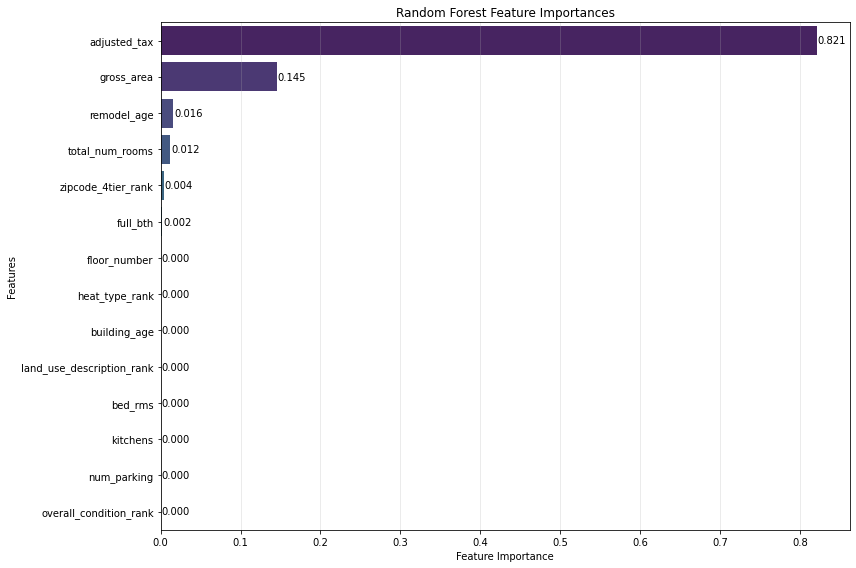

In [55]:
# Plot 3: Seaborn barplot
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)

sns.barplot(
    data=top_features, 
    x='importance', 
    y='feature', 
    palette='viridis'
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importances')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_features['importance']):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

## Model 8: XGBoost Regressor

In [56]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [57]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [58]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

In [59]:
# Train model with watchlist
model = xgb.train(
    xgb_params, 
    dtrain, 
    num_boost_round=100,
    evals=watchlist,          
    verbose_eval=10
)

[0]	train-rmse:9.05282	val-rmse:9.05245
[10]	train-rmse:0.29774	val-rmse:0.43794
[20]	train-rmse:0.13943	val-rmse:0.33083
[30]	train-rmse:0.13401	val-rmse:0.47707
[40]	train-rmse:0.12976	val-rmse:0.49480
[50]	train-rmse:0.12653	val-rmse:0.47499
[60]	train-rmse:0.12302	val-rmse:0.47726
[70]	train-rmse:0.12084	val-rmse:0.47895
[80]	train-rmse:0.11972	val-rmse:0.49788
[90]	train-rmse:0.11769	val-rmse:0.47472
[99]	train-rmse:0.11617	val-rmse:0.47982


In [60]:
y_pred = model.predict(dval)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Final RMSE: {rmse:.4f}")

Final RMSE: 0.4798


In [64]:
# Define parameter grids to test
param_grids = {
    'eta':  [0.1, 0.3, 0.5],
    'max_depth': [3,4],
    'learning_rate': [0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8],
    'colsample_bytree': [1.0],
    'n_estimators': [100,200]
}

# Convert to DMatrix for faster training
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
watchlist = [(dtrain, 'train'), (dval, 'val')]

# Generate all parameter combinations
param_combinations = list(itertools.product(
    param_grids['eta'],
    param_grids['max_depth'],
    param_grids['learning_rate'], 
    param_grids['min_child_weight'],
    param_grids['subsample'],
    param_grids['colsample_bytree'],
    param_grids['n_estimators']
))

print(f"🔍 XGBOOST HYPERPARAMETER SEARCH")
print(f"=" * 60)
print(f"Total combinations to test: {len(param_combinations):,}")
print(f"This may take a while...\n")

# Store results
results = []
best_rmse = float('inf')
best_xg = None

# Loop through all combinations
for i, (eta, max_depth, learning_rate, min_child_weight, subsample, colsample_bytree, n_estimators) in enumerate(param_combinations):
    
    print(f"[{i+1:3d}/{len(param_combinations)}] Testing: eta={eta}, depth={max_depth}, lr={learning_rate}, "
          f"child={min_child_weight}, sub={subsample}, col={colsample_bytree}, n_est={n_estimators}")
    
    # Set parameters
    params = {
        'eta': eta,
        'objective': 'reg:squarederror',
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'min_child_weight': min_child_weight,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'eval_metric': 'rmse',
        'seed': 1
    }
    
    try:
        # Train model
        model = xgb.train(
            params,
            dtrain,
            num_boost_round=n_estimators,
            evals=watchlist,
            verbose_eval=False,  # Changed to False to reduce output
            early_stopping_rounds=20
        )
        
        # ✅ ADD THESE PREDICTION LINES:
        # Make predictions on validation set
        y_pred = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
        val_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        
        # Also get training predictions for overfitting analysis
        y_pred_train = model.predict(dtrain, iteration_range=(0, model.best_iteration + 1))
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        
        best_iteration = model.best_iteration + 1
        
        # Store results
        result = {
            'eta': eta,
            'max_depth': max_depth,
            'learning_rate': learning_rate,
            'min_child_weight': min_child_weight,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'n_estimators': n_estimators,
            'best_iteration': best_iteration,
            'train_rmse': train_rmse,     
            'val_rmse': val_rmse,
            'model': model
        }
        
        results.append(result)
        
        # Check if this is the best so far
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_xg = result.copy()
            print(f"    🎯 NEW BEST! Train: {train_rmse:.6f}, Val: {val_rmse:.6f} (iter {best_iteration})")
        else:
            print(f"    Train: {train_rmse:.6f}, Val: {val_rmse:.6f} (iter {best_iteration})")
            
    except Exception as e:
        print(f"    ❌ Error: {e}")
        continue

print(f"\n🏆 HYPERPARAMETER SEARCH COMPLETE!")
print(f"=" * 60)
print(f"Best Parameters {best_xg}")

best_xg = pd.Series(best_xg).to_frame().T

🔍 XGBOOST HYPERPARAMETER SEARCH
Total combinations to test: 36
This may take a while...

[  1/36] Testing: eta=0.1, depth=3, lr=0.2, child=1, sub=0.8, col=1.0, n_est=100
    🎯 NEW BEST! Train: 0.167396, Val: 0.199876 (iter 27)
[  2/36] Testing: eta=0.1, depth=3, lr=0.2, child=1, sub=0.8, col=1.0, n_est=200
    Train: 0.167396, Val: 0.199876 (iter 27)
[  3/36] Testing: eta=0.1, depth=3, lr=0.2, child=3, sub=0.8, col=1.0, n_est=100
    Train: 0.167396, Val: 0.199876 (iter 27)
[  4/36] Testing: eta=0.1, depth=3, lr=0.2, child=3, sub=0.8, col=1.0, n_est=200
    Train: 0.167396, Val: 0.199876 (iter 27)
[  5/36] Testing: eta=0.1, depth=3, lr=0.2, child=5, sub=0.8, col=1.0, n_est=100
    Train: 0.167396, Val: 0.199876 (iter 27)
[  6/36] Testing: eta=0.1, depth=3, lr=0.2, child=5, sub=0.8, col=1.0, n_est=200
    Train: 0.167396, Val: 0.199876 (iter 27)
[  7/36] Testing: eta=0.1, depth=4, lr=0.2, child=1, sub=0.8, col=1.0, n_est=100
    Train: 0.157038, Val: 0.236705 (iter 28)
[  8/36] Testing:

## Model Comparison

In [69]:
subset_ols = ols_best[['train_rmse', 'val_rmse', 'model']]
subset_poly = best_poly[['train_rmse', 'val_rmse', 'model']]
subset_ridge = best_ridge[['train_rmse', 'val_rmse', 'model']]
subset_lasso = best_lasso[['train_rmse', 'val_rmse', 'model']]
subset_elasticnet = best_elasticnet[['train_rmse', 'val_rmse', 'model']]
subset_rf = best_rf[['train_rmse', 'val_rmse', 'model']]
subset_xg = best_xg[['train_rmse', 'val_rmse', 'model']]

In [70]:
model_compar_df = pd.concat([subset_ols,subset_poly, subset_ridge,subset_lasso,subset_elasticnet,subset_rf, subset_xg])
model_compar_df = model_compar_df.reset_index(drop=True)

In [71]:
model_compar_df['train_val_rmse_diff'] = model_compar_df['train_rmse']-model_compar_df['val_rmse']
sorted_model_compar_df = model_compar_df.sort_values('train_val_rmse_diff', ascending=False);sorted_model_compar_df

,train_rmse,val_rmse,model,train_val_rmse_diff
5,0.235707,0.180537,"(DecisionTreeRegressor(max_depth=5, max_featur...",0.05517
2,0.229411,0.226519,"Ridge(alpha=0.01, random_state=1)",0.002893
3,0.217484,0.21487,"Lasso(alpha=0.01, max_iter=2000, random_state=1)",0.002614
4,0.208148,0.205897,"ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=...",0.00225
0,0.207588,0.205436,LinearRegression(),0.002152
1,0.198824,0.197416,"(PolynomialFeatures(include_bias=False), Linea...",0.001408
6,0.167396,0.199876,<xgboost.core.Booster object at 0x7fd518d34700>,-0.03248


So, the two obvious choices not to choose from are the Random Forest and xgboost. We would prefer to keep the values of train and validation rsme's about the same. I'll go with ElasticNet model. Majority of the models have a residual rsme of 0.002

In [77]:
best_elasticnet['model'][0]

ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=2000, random_state=1)